### Подготовка данных

In [ ]:
import warnings
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
time_series = pd.read_csv(url)

time_series.sample(5)

,Month,Passengers
41,1952-06,218
82,1955-11,237
32,1951-09,184
118,1958-11,310
7,1949-08,148


In [ ]:
len(time_series)

144

In [ ]:
time_series.isnull().sum()

,0
Month,0
Passengers,0


In [ ]:
time_series.dtypes

,0
Month,object
Passengers,int64


In [ ]:
time_series['Month'] = pd.to_datetime(time_series['Month'])
time_series.set_index('Month', inplace=True)

In [ ]:
time_series.dtypes

,0
Passengers,int64


In [ ]:
time_series.sample(5)

,Passengers
Month,
1957-06-01,422
1950-01-01,115
1958-12-01,337
1960-06-01,535
1952-09-01,209


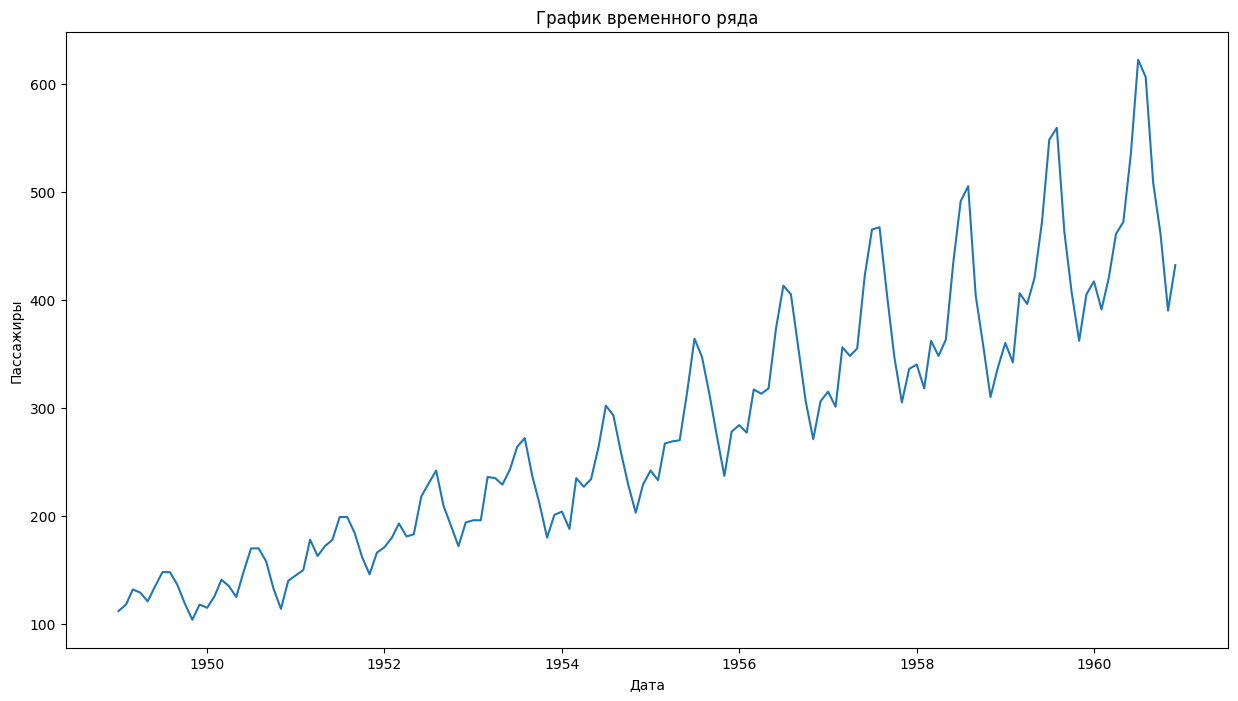

In [ ]:
plt.figure(figsize=(15,8))
plt.plot(time_series['Passengers'])
plt.title('График временного ряда')
plt.xlabel('Дата')
plt.ylabel('Пассажиры')
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

In [ ]:
train, test = train_test_split(time_series, test_size=0.2, shuffle=False)

In [ ]:
train.shape

(115, 1)

In [ ]:
test.shape

(29, 1)

In [ ]:
test.head()

,Passengers
Month,
1958-08-01,505
1958-09-01,404
1958-10-01,359
1958-11-01,310
1958-12-01,337


### Обучение модели

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

class MLARWrapper:
    """
    Обучает ML‑модель на лагах и эмулирует интерфейс statsmodels ARIMA:
    - resid   (остатки на обучающей выборке)
    - forecast(steps)
    - simulate(nsimulations, anchor='end', repetitions=1, random_errors=None)
    """
    def __init__(self, model, lags=12):
        """
        model : объект sklearn‑регрессора (например, RandomForestRegressor)
        lags  : количество запаздывающих наблюдений (p)
        """
        self.model = model
        self.lags = lags

    def fit(self, train_series):
        """
        train_series : pd.Series или np.array – одномерный временной ряд
        """
        y = train_series.values.reshape(-1, 1) if isinstance(train_series, pd.Series) else train_series
        X, y_target = self._build_lags(y, self.lags)
        self.model.fit(X, y_target)

        # Сохраняем ряд для дальнейшего прогнозирования
        self._fitted_series = y.ravel()
        # Вычисляем остатки на обучении
        y_pred = self.model.predict(X)
        self.resid = y_target - y_pred          # атрибут, как у ARIMA
        self._last_vals = y[-self.lags:].ravel() # последние известные значения
        return self

    def _build_lags(self, y, p):
        """Строит матрицу лагов и целевой вектор."""
        n = len(y)
        X = np.zeros((n-p, p))
        for i in range(p, n):
            X[i-p] = y[i-p:i].ravel()
        y_target = y[p:].ravel()
        return X, y_target

    def predict(self, X):
        """Предсказание по матрице признаков (лагов)."""
        return self.model.predict(X)

    def forecast(self, steps):
        """Рекурсивный точечный прогноз на 'steps' шагов."""
        forecast_vals = np.zeros(steps)
        last_vals = self._last_vals.copy()  # стартовый вектор лагов
        for i in range(steps):
            pred = self.model.predict(last_vals.reshape(1, -1))[0]
            forecast_vals[i] = pred
            # сдвигаем лаги: добавляем новый прогноз
            last_vals = np.append(last_vals[1:], pred)
        return forecast_vals

    def simulate(self, nsimulations, anchor='end', repetitions=1, random_errors=None):
        """
        Симуляция будущих значений с возможность передачи пользовательских ошибок.
        random_errors : np.array формы (steps,) или (steps,1) – шум, добавляемый после predict.
        """
        # В данный момент repetitions не используется, можно игнорировать
        steps = nsimulations
        sim_vals = np.zeros(steps)
        last_vals = self._last_vals.copy()
        errors = random_errors.ravel() if random_errors is not None else np.zeros(steps)
        for i in range(steps):
            pred = self.model.predict(last_vals.reshape(1, -1))[0]
            sim_vals[i] = pred + errors[i]
            # обновляем лаги
            last_vals = np.append(last_vals[1:], sim_vals[i])
        return sim_vals

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostRegressor

ml_model = MLARWrapper(
    model=CatBoostRegressor(
        iterations=300,
        learning_rate=0.1,
        depth=5,
        l2_leaf_reg=5, # без регуляризации интервалы поулчаются совсем узкие
        random_seed=42,
        verbose=0
    ),
    lags=12)

fitted_model = ml_model.fit(train['Passengers'])

### Реализации бутстрапа

In [ ]:
def residual_bootstrap(fitted_model, steps, n_bootstrap=1000):
    residuals = fitted_model.resid
    forecasts = []

    for _ in range(n_bootstrap):
        boot_resid = np.random.choice(residuals, size=steps, replace=True)
        # Симуляция будущих значений с учётом структуры модели
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',          # начать с конца обучающей выборки
            repetitions=1,
            random_errors=boot_resid.reshape(-1,1)  # передаём бутстреп-остатки
        )

        sim_values = np.asarray(sim).flatten()
        # Если нужно добавить внешний тренд/сезонность – убедитесь, что модель их не содержит
        # В противном случае не применяйте add_trend_and_seasonal повторно.
        boot_forecast = sim_values
        forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [ ]:
# max - половина максимальной ошибки
# mean - половина средней ошибки
# median - половина медианной ошибки
def naive_bootstraps(fitted_model, steps, method, n_bootstrap=1000):
    residuals = fitted_model.resid
    abs_resids = np.abs(residuals)

    if method == 'max':
        error_magnitude = np.max(abs_resids) / 2.0
        # Равномерное распределение на [-mag, mag]
        sampler = lambda: np.random.uniform(-error_magnitude, error_magnitude, size=steps)
    elif method == 'mean':
        error_magnitude = np.mean(abs_resids) / 2.0
        # Нормальное распределение со стандартным отклонением = mag
        sampler = lambda: np.random.normal(0, error_magnitude, size=steps)
    elif method == 'median':
        error_magnitude = np.median(abs_resids) / 2.0
        sampler = lambda: np.random.normal(0, error_magnitude, size=steps)
    else:
        raise ValueError("[naive] no such method ")

    forecasts = []

    for _ in range(n_bootstrap):
        boot_resid = sampler()                     # случайный шум
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [ ]:
!pip install arch

import arch
from arch.bootstrap import MovingBlockBootstrap

def arch_block_bootstrap(fitted_model, steps, block_length=12, n_bootstrap=1000):
    residuals = fitted_model.resid
    point_forecast = fitted_model.forecast(steps=steps)

    mbb = MovingBlockBootstrap(block_length, residuals)
    forecasts = []

    for data in mbb.bootstrap(n_bootstrap):
        # data[0][0] содержит сгенерированный ряд остатков
        boot_resid = data[0][0]

        if len(boot_resid) >= steps:
            boot_forecast = point_forecast + boot_resid[:steps]
            forecasts.append(boot_forecast)
        else:
            # Если остатков не хватает, повторяем их циклически
            repeated_resid = np.tile(boot_resid, int(np.ceil(steps / len(boot_resid))))[:steps]
            boot_forecast = point_forecast + repeated_resid
            forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)

    return lower, upper, forecasts

In [ ]:
!pip install tsbootstrap

from tsbootstrap import WholeSieveBootstrap

def sieve_bootstrap(fitted_model, steps, min_lag=1, max_lag=12, n_bootstrap=1000, random_state=42):
    residuals = fitted_model.resid

    centered_resid = residuals - np.mean(residuals)

    sieve = WholeSieveBootstrap(n_bootstraps=n_bootstrap)

    boot_residuals = sieve.bootstrap(centered_resid)

    boot_residuals_list = []
    for _ in range(n_bootstrap):
        boot_residuals_list.append(next(boot_residuals))
    boot_residuals = np.array(boot_residuals_list)

    forecasts = []
    for i in range(n_bootstrap):
        boot_resid = boot_residuals[i, :]
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [ ]:
from tsbootstrap import MovingBlockBootstrap as tsbootstrap_mbb

def tsbootstrap_block_bootstrap(fitted_model, steps, block_length=12, n_bootstrap=1000, random_state=42):
    residuals = fitted_model.resid

    centered_resid = residuals - np.mean(residuals)

    mbb = tsbootstrap_mbb(n_bootstraps=n_bootstrap, rng=random_state, block_length=block_length)

    boot_residuals = mbb.bootstrap(centered_resid)

    boot_residuals_list = []
    for _ in range(n_bootstrap):
        boot_residuals_list.append(next(boot_residuals))
    boot_residuals = np.array(boot_residuals_list)

    forecasts = []
    for i in range(n_bootstrap):
        boot_resid = boot_residuals[i, :]
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

### Сравнение методов

In [ ]:
def evaluate(true_values, lower, upper):
    true_vals = np.array(true_values).flatten()

    # доля истинных значений, попавших в интервал
    coverage = np.mean((lower <= true_vals[:len(lower)]) & (true_vals[:len(lower)] <= upper))

    # средняя ширина интервала
    avg_width = np.mean(upper - lower)
    return coverage, avg_width

forecast_steps = 24
forecast = fitted_model.forecast(steps=forecast_steps)

test_values = test.values.flatten()[:forecast_steps]

results = {}

# Residual Bootstrap
try:
    lower_res_c, upper_res_c, all_forecasts_res_c  = residual_bootstrap(fitted_model, forecast_steps)
    coverage_res_c, width_res_c = evaluate(test_values, lower_res_c, upper_res_c)
    results['Residual Bootstrap Correct'] = {'coverage': coverage_res_c, 'width': width_res_c, 'lower': lower_res_c, 'upper': upper_res_c}
    print("Residual Bootstrap Correct - OK")
except Exception as e:
    print(f"Residual Bootstrap Correct error: {e}")

# Naive
try:
    for method in ["max", "mean", "median"]:
        lower_naive, upper_naive, all_forecasts_naive  = naive_bootstraps(fitted_model, forecast_steps, method)
        coverage_naive, width_naive = evaluate(test_values, lower_naive, upper_naive)
        results['Naive-' + method] = {'coverage': coverage_naive, 'width': width_naive, 'lower': lower_naive, 'upper': upper_naive}
        print(f" ### Naive {method} - OK")
    print("Naive - OK")
except Exception as e:
    print(f"Naive: {e}")

# ARCH block Bootstrap
try:
    lower_arch, upper_arch, _ = arch_block_bootstrap(fitted_model, forecast_steps, block_length=12)
    coverage_arch, width_arch = evaluate(test_values, lower_arch, upper_arch)
    results['ARCH Block Bootstrap'] = {'coverage': coverage_arch, 'width': width_arch, 'lower': lower_arch, 'upper': upper_arch}
    print("ARCH Block Bootstrap - OK")
except Exception as e:
    print(f"ARCH Block Bootstrap error: {e}")

# Sieve bootstrap
try:
    lower_sieve, upper_sieve, _ = sieve_bootstrap(fitted_model, forecast_steps)
    coverage_sieve, width_sieve = evaluate(test_values, lower_sieve, upper_sieve)
    results['Sieve Bootstrap'] = {'coverage': coverage_sieve, 'width': width_sieve, 'lower': lower_sieve, 'upper': upper_sieve}
    print("Sieve Bootstrap - OK")
except Exception as e:
    print(f"Sieve Bootstrap error: {e}")

# tsbootstrap block bootstrap
try:
    lower_block, upper_block, _ = tsbootstrap_block_bootstrap(fitted_model, forecast_steps)
    coverage_block, width_block = evaluate(test_values, lower_block, upper_block)
    results['Tsbootstrap Block Bootstrap'] = {'coverage': coverage_block, 'width': width_block, 'lower': lower_block, 'upper': upper_block}
    print("Tsbootstrap Block Bootstrap - OK")
except Exception as e:
    print(f"Tsbootstrap Block Bootstrap error: {e}")

results_df = pd.DataFrame(results).T[['coverage', 'width']]
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ:")
print("="*50)
print(results_df)

Residual Bootstrap Correct - OK
 ### Naive max - OK
 ### Naive mean - OK
 ### Naive median - OK
Naive - OK
ARCH Block Bootstrap - OK
[-0.97178838 -1.54521285 -0.81447247 -1.27515866 -2.75746343 -0.91667662
 -0.58402635  1.65658705 -1.09083863 -1.54506824 -2.61343716  3.10096171
  2.60588266  1.00853988  3.41246276  1.96916184  4.04599843 -1.93315393
  3.11311816  2.71928708  0.61460362 -2.40157761 -1.42881295 -1.04219457
 -2.82914173 -2.7547966   2.01424962 -1.01622585 -3.85973816  1.52926349
 -0.88874731  3.36225707 -4.53003892  0.47131613 -2.38538421  2.49345822
  2.16239627  0.59459935  6.07658062  4.50068642  1.17483302  1.55403806
  5.00332681  2.91033364 -1.8031169  -1.74780275 -6.77758233  0.55324746
 -2.48131962 -6.74869314 -0.57937135 -6.27987048 -1.32339471 -2.79321813
  0.8275018  -0.86302105 -3.46765096 -1.0662973  -0.42764972  1.95706327
  4.16201731 -0.40108156  3.21448369  4.99311969 -2.37432711  0.50686818
  5.45482578 -0.81273384  2.48128657  0.92492993 -2.54722269  3.

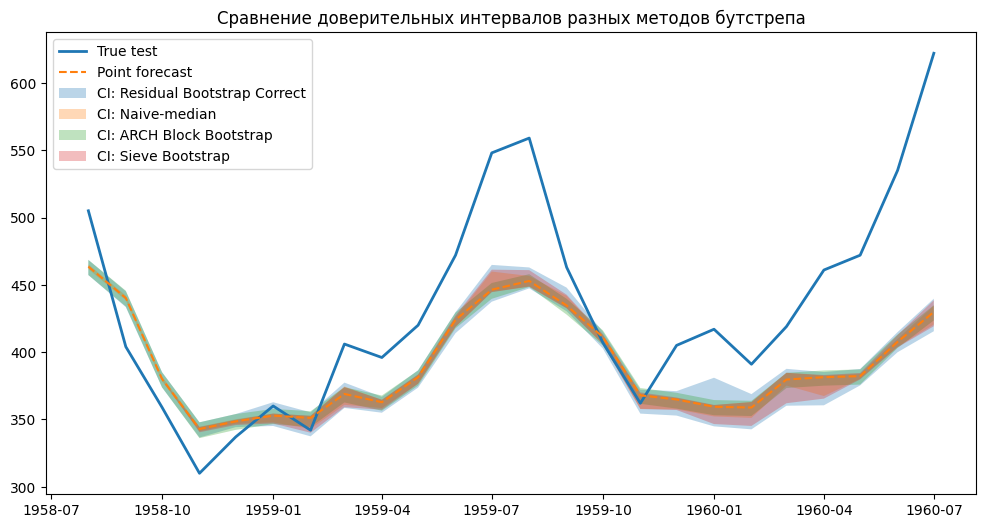

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(test.index[:forecast_steps], test_values, label='True test', linewidth=2)
plt.plot(test.index[:forecast_steps], forecast[:forecast_steps], label='Point forecast', linestyle='--')

to_plot = ['Residual Bootstrap Correct', 'Naive-median', 'ARCH Block Bootstrap', 'Sieve Bootstrap']

for name in results.keys():
    if name not in to_plot:
        continue

    lower = results[name]['lower']
    upper = results[name]['upper']

    plt.fill_between(test.index[:forecast_steps], lower, upper, alpha=0.3, label=f'CI: {name}')

plt.legend()
plt.title('Сравнение доверительных интервалов разных методов бутстрепа')
plt.show()